# Forecast All-Modes Matrices — BU / HS × 2040 / 2050

Step 1 of the forecast hierarchy

$$T^{ALL}_{2022} \;\rightarrow\; T^{ALL}_{2040/2050} \;\rightarrow\; \text{mode split} \;\rightarrow\; T^{LRT}$$

Grows the 2022 all-modes area matrix (`Output/transit/all_adjusted_area_2022.csv`,
25×25 aggregated research areas, 276,355 AM-peak trips) to four scenario-years —
**BU-2040, BU-2050, HS-2040, HS-2050** — by Furness/IPF with demographically grown
margins, per the scenario-comparison finding
(`Demographic_scenario_comparison.ipynb`) that each scenario-year needs its own
matrix.

**Methodology decisions**

1. **Productions/attractions, not cell factors.** Margins are grown per area —
   `POPULATION` on the origin side (AM productions), `EMPL_TOT` on the destination
   side (AM attractions) — and the matrix is Furnessed to the new margins; the
   base destination structure carries over, cells are never scaled directly.
2. **Constant per-person trip rates.** Neither THS source carries person
   demographics (the 2017 trips file and the 2018 activities/households files have
   no age/worker/student fields), so segment rates cannot be derived from the
   survey. With rates held constant they cancel in the growth ratio:
   $G_i = \frac{Pop_i^{y}\,r_i}{Pop_i^{2022}\,r_i} = \frac{Pop_i^{y}}{Pop_i^{2022}}$ —
   the survey rate is already embedded in the base matrix and is **not** applied
   again. Behavioral change (telework, motorization, aging, income) is a separate
   scenario layer, deliberately not modeled here.
3. **Base-year bridge.** The seed matrix is 2022 but the demographic base is 2020,
   so per-area 2022 levels are interpolated the same way the vintage alignment
   built the 2022 matrix: $X_{2022} = X_{2020}\,(X_{2025}^{BU}/X_{2020})^{2/5}$
   (both scenarios share this base — the 2022 matrix is scenario-independent).
4. **Employment-district fallback and new residents.** Areas with 2022 population
   < 500 (Matam, Kiryat Nahum, Namal, Hutzot, Hamifrats, Haifa Airport) take the
   employment factor on the origin side (the vintage-alignment convention) — but
   under HS, Matam and Kiryat Nahum gain genuinely new residential population
   (≈ 9.7k / 3.5k by 2050) that a ratio cannot represent. Their production is
   added explicitly: $O_i^{+} = \Delta Pop_i \cdot \hat r$, where $\hat r$ is the
   in-matrix production rate (base origins / 2022 population) median across
   populated areas — self-calibrated to this matrix, so no external rate enters.
5. **Production-driven balancing.** Attraction targets are rescaled to the
   production total before IPF.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 220)
POP_MIN = 500
SCEN = ['BU_2040', 'BU_2050', 'HS_2040', 'HS_2050']

seed = pd.read_csv('Output/transit/all_adjusted_area_2022.csv', index_col=0)
seed.columns = seed.columns.astype(int)
areas = seed.index.tolist()

sub = pd.read_excel('Input/Submatrix_tazs.xlsx')
taz_to_area = sub.set_index('TAZ')['AggAreaCode']
legend = pd.read_csv('Output/ths2017/study_taz/submatrices/area_legend.csv').set_index('AggAreaCode')

def area_sums(path):
    z = pd.read_csv(path, encoding='utf-8', encoding_errors='replace')
    a = z.groupby(z.TAZ_ID.map(taz_to_area))[['POPULATION', 'EMPL_TOT']].sum()
    a.index = a.index.astype(int)
    return a.reindex(areas)

z20 = area_sums('Input/Demographic_Forecast/Zonal_2020.csv')
z25 = area_sums('Input/Zonal_BU_2025.csv')
zs = {s: area_sums(f'Input/Demographic_Forecast/Zonal_{s}.csv') for s in SCEN}

# 2022 bridge, same interpolation the vintage alignment used for the seed matrix
with np.errstate(divide='ignore', invalid='ignore'):
    ratio = (z25 / z20) ** (2 / 5)
z22 = (z20 * ratio.fillna(1.0)).fillna(0.0)
print('2022 bridged research-area totals:',
      {c: int(z22[c].sum()) for c in z22.columns})

2022 bridged research-area totals: {'POPULATION': 417891, 'EMPL_TOT': 236456}


In [2]:
O_base, D_base = seed.sum(axis=1), seed.sum(axis=0)
populated = z22.POPULATION >= POP_MIN
r_hat = (O_base[populated] / z22.POPULATION[populated]).median()
print(f'in-matrix production rate r_hat = {r_hat:.3f} AM trips per resident '
      f'(median over {populated.sum()} populated areas)')

def targets(s):
    zy = zs[s]
    g_emp = zy.EMPL_TOT / z22.EMPL_TOT
    with np.errstate(divide='ignore', invalid='ignore'):
        g_pop = zy.POPULATION / z22.POPULATION
    O_t = np.where(populated, O_base * g_pop,
                   O_base * g_emp + np.maximum(zy.POPULATION - z22.POPULATION, 0) * r_hat)
    O_t = pd.Series(O_t, index=areas)
    D_t = D_base * g_emp
    D_t = D_t * O_t.sum() / D_t.sum()          # production-driven balance
    return O_t, D_t, g_pop, g_emp

def ipf(seed, O_t, D_t, tol=1e-8, iters=1000):
    m = seed.values.astype(float).copy()
    for it in range(iters):
        m *= (O_t.values / m.sum(axis=1))[:, None]
        m *= (D_t.values / m.sum(axis=0))[None, :]
        dev = np.abs(m.sum(axis=1) - O_t.values).sum() / O_t.sum()
        if dev < tol:
            break
    return pd.DataFrame(m, index=seed.index, columns=seed.columns), it + 1, dev

os.makedirs('Output/forecast', exist_ok=True)
mats, diag = {}, []
for s in SCEN:
    O_t, D_t, g_pop, g_emp = targets(s)
    mats[s], its, dev = ipf(seed, O_t, D_t)
    mats[s].round(2).to_csv(f'Output/forecast/all_modes_area_{s}.csv')
    diag.append({'scenario': s, 'trips': mats[s].values.sum(), 'growth_vs_2022':
                 mats[s].values.sum() / seed.values.sum(), 'ipf_iters': its, 'margin_dev': dev})
print(pd.DataFrame(diag).round(4).to_string(index=False))

in-matrix production rate r_hat = 0.654 AM trips per resident (median over 19 populated areas)
scenario       trips  growth_vs_2022  ipf_iters  margin_dev
 BU_2040 380288.3244          1.3761         80         0.0
 BU_2050 459831.4460          1.6639         96         0.0
 HS_2040 384839.6311          1.3926         87         0.0
 HS_2050 461083.4408          1.6684         95         0.0


## Margins and growth factors per area

In [3]:
rows = []
for s in SCEN:
    O_t, D_t, g_pop, g_emp = targets(s)
    for a in areas:
        rows.append({'AggAreaCode': a, 'scenario': s,
                     'g_pop': g_pop[a] if populated[a] else np.nan, 'g_emp': g_emp[a],
                     'O_2022': O_base[a], 'O_target': O_t[a],
                     'D_2022': D_base[a], 'D_target': D_t[a]})
marg = pd.DataFrame(rows)
marg.insert(1, 'AggAreaName', marg.AggAreaCode.map(legend.AggAreaName))
marg.insert(2, 'IsLRT_Corridor', marg.AggAreaCode.map(legend.IsLRT_Corridor))
marg.round(3).to_csv('Output/forecast/forecast_margins_growth.csv', index=False)

wide = marg.pivot_table(index=['AggAreaCode', 'AggAreaName', 'IsLRT_Corridor'],
                        columns='scenario', values='O_target')
wide.insert(0, 'O_2022', O_base.values)
print(wide.round(0).astype(int).to_string())

scenario                                          O_2022  BU_2040  BU_2050  HS_2040  HS_2050
AggAreaCode AggAreaName           IsLRT_Corridor                                            
1           TiratCarmel            1               23098    58643   100315    30392    32200
2           Matam                  1                1507     1769     1930     4664     7989
3           Neot Peres             1                1033      995      949     2421     3382
4           Neve David             1                4240     4020     3797     4791     5128
5           Ein Hayam              1                5345     5722     5767     6284     6893
6           Bat Galim              1                5448     5364     5181     7840    10228
7           Kiryat Eliezer         1                5571     6001     6618     6203     9322
8           Hamoshava              1                3635     4695     5122     4647     5018
9           Lower City             1                3731     4994     

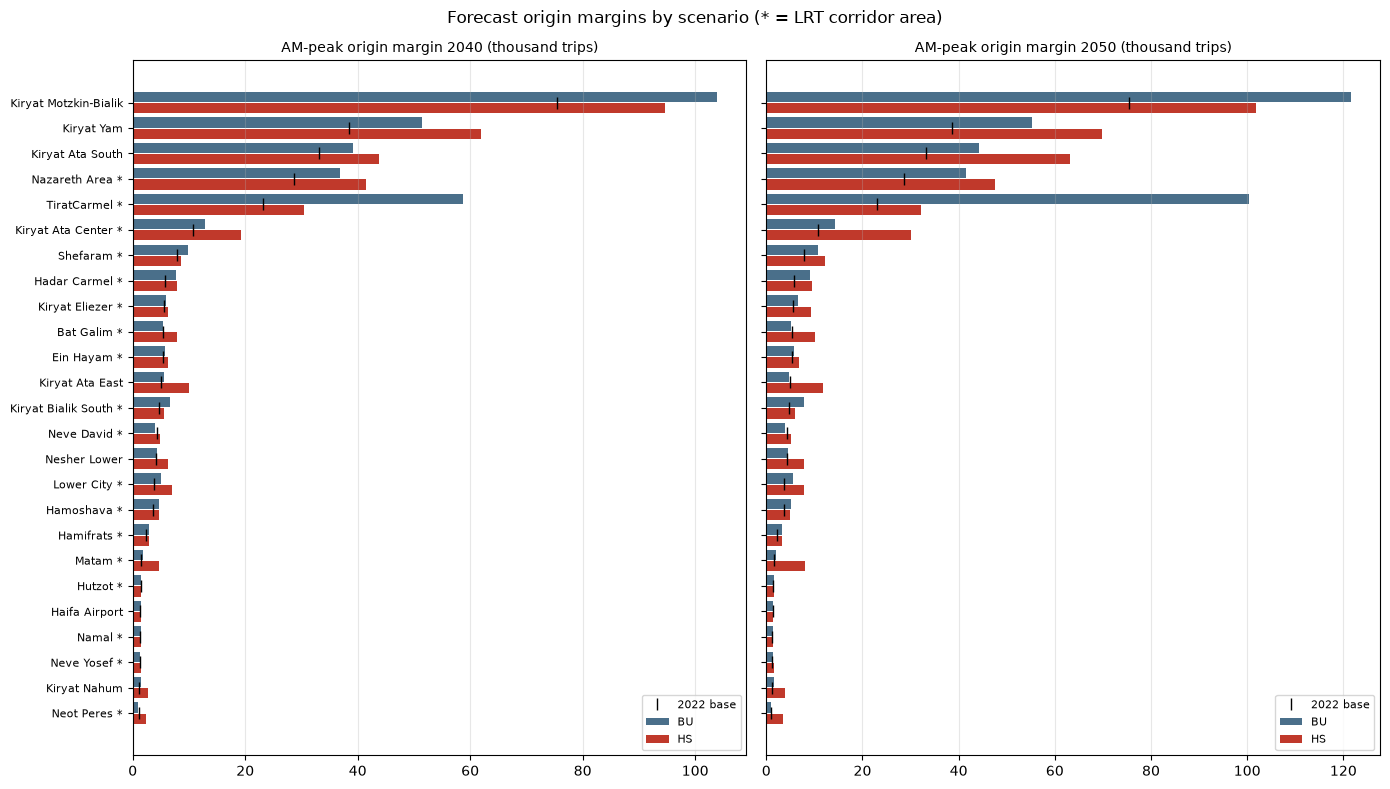

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
w = wide.reset_index().sort_values('O_2022')
ypos = np.arange(len(w))
for ax, yr in zip(axes, ['2040', '2050']):
    ax.barh(ypos + 0.22, w[f'BU_{yr}'] / 1000, height=0.4, label='BU', color='#4a6f8a')
    ax.barh(ypos - 0.22, w[f'HS_{yr}'] / 1000, height=0.4, label='HS', color='#c0392b')
    ax.plot(w['O_2022'] / 1000, ypos, 'k|', markersize=9, label='2022 base')
    ax.set_yticks(ypos)
    ax.set_yticklabels([f"{n}{' *' if c == 1 else ''}" for n, c in
                        zip(w.AggAreaName, w.IsLRT_Corridor)], fontsize=8)
    ax.set_title(f'AM-peak origin margin {yr} (thousand trips)', fontsize=10)
    ax.legend(fontsize=8); ax.grid(axis='x', alpha=0.3)
fig.suptitle('Forecast origin margins by scenario (* = LRT corridor area)', y=0.98)
fig.tight_layout()
fig.savefig('Output/figures/forecast_margins_by_scenario.png', dpi=150, bbox_inches='tight')
plt.show()

## How different are the four matrices?

In [5]:
for yr in ['2040', '2050']:
    bu, hs = mats[f'BU_{yr}'], mats[f'HS_{yr}']
    mask = bu.values > 50
    pct = (hs.values[mask] / bu.values[mask] - 1) * 100
    corr_ids = legend[legend.IsLRT_Corridor == 1].index
    in_corr = lambda m: m.loc[m.index.isin(corr_ids), m.columns.isin(corr_ids)].values.sum()
    print(f'{yr}: HS vs BU — {(np.abs(pct) > 10).sum()} of {mask.sum()} cells (>50 trips) '
          f'differ by >10% (median |diff| {np.median(np.abs(pct)):.0f}%); '
          f'in-corridor trips BU {in_corr(bu):,.0f} vs HS {in_corr(hs):,.0f}')

print('\nTirat Carmel origin trips:', {k: round(m.loc[1].sum()) for k, m in mats.items()},
      'vs 2022:', round(O_base[1]))
print('Matam origin trips:       ', {k: round(m.loc[2].sum()) for k, m in mats.items()},
      'vs 2022:', round(O_base[2]))

2040: HS vs BU — 228 of 295 cells (>50 trips) differ by >10% (median |diff| 25%); in-corridor trips BU 150,616 vs HS 137,668
2050: HS vs BU — 254 of 295 cells (>50 trips) differ by >10% (median |diff| 40%); in-corridor trips BU 192,237 vs HS 166,702

Tirat Carmel origin trips: {'BU_2040': 58643, 'BU_2050': 100315, 'HS_2040': 30392, 'HS_2050': 32200} vs 2022: 23098
Matam origin trips:        {'BU_2040': 1769, 'BU_2050': 1930, 'HS_2040': 4664, 'HS_2050': 7989} vs 2022: 1507


## Outputs

- `Output/forecast/all_modes_area_{BU,HS}_{2040,2050}.csv` — the four all-modes
  AM-peak matrices (25×25 aggregated areas), each IPF-converged to its
  scenario-year margins.
- `Output/forecast/forecast_margins_growth.csv` — per area × scenario: growth
  factors and origin/destination targets.
- `Output/figures/forecast_margins_by_scenario.png`.

**Caveats.** (1) For Matam / Kiryat Nahum the seed row is the employment-district
outflow pattern; their new HS residents inherit it, which is weak evidence at TAZ
level but acceptable at the 25-area resolution — revisit if these areas become
material to LRT boardings. (2) The three small rural areas (Adi, Alon Hagalil,
Tzipori) are outside the 25-area matrix by earlier scoping. (3) Constant trip
rates: any telework/motorization/aging adjustment belongs in a separate,
explicitly scenario-based layer on top of these matrices.

**Next**: mode split on the four matrices, then LRT capture.